# Adapted Altman-Style Bankruptcy Risk Screening


## 1. Project Overview

This project builds a small **financial distress screening tool** based on the **Altman Z-Score** model. Using firm-level accounting ratios from the Kaggle Taiwan Economic Journal (TEJ) Bankruptcy Prediction Dataset, the notebook calculates a composite Z-Score for each observation and examines whether firms labelled as bankrupt tend to have weaker financial profiles.

The analytical goal is not to train a complex machine-learning classifier. Instead, it is to show how a classic finance model can be implemented in Python and turned into a clear, interpretable risk-analysis product. The final output is designed for **finance students, beginner investors, and junior analysts** who want a simple way to understand how liquidity, retained profitability, earnings power, solvency, and operating efficiency relate to bankruptcy risk.


## 2. Problem Definition

This notebook addresses one focused question:

**Can the Altman Z-Score meaningfully separate bankrupt firms from non-bankrupt firms in this dataset, and which underlying financial dimensions contribute most to that separation?**

To answer this question, the notebook:

- maps raw accounting variables into the five components of the Altman Z-Score
- computes a firm-level **Z-Score**
- compares score distributions between bankrupt and non-bankrupt firms
- examines the relationship between each component ratio and bankruptcy status
- checks whether the main result is robust after reducing the influence of extreme values

The intended user is someone who needs an **interpretable early-warning indicator**, rather than a black-box predictive model.



## 3. Dataset Description

The dataset used in this project is the Taiwan Economic Journal (TEJ) Bankruptcy Prediction Dataset, obtained from Kaggle.

- Source: Kaggle  
- Access date: 2026/04/15
- Time period covered: 2015–2024

This dataset was selected because it contains multiple financial indicators relevant to financial management analysis

## 4. Methodology

This project applies an **adapted Altman-style distress score** rather than claiming a perfect reconstruction of the original Altman Z-Score. The reason is that the dataset does not provide all original accounting items in raw statement form. Instead, it provides several financial ratios that are the closest available proxies for the five classic Altman dimensions.

The composite score used in this notebook is:

$$
Z = 1.2X_1 + 1.4X_2 + 3.3X_3 + 0.6X_4 + 1.0X_5
$$

where:

- $X_1$ = Working Capital / Total Assets, a short-term liquidity measure
- $X_2$ = Retained Earnings / Total Assets, a proxy for cumulative profitability and maturity
- $X_3$ = ROA(C) before interest and depreciation before interest, used here as the closest available proxy for core earnings power
- $X_4$ = Equity / Liability, a solvency and capital-structure measure
- $X_5$ = Total Income / Total Expense, used here as a broad operating efficiency proxy

A **higher score** suggests stronger financial health, while a **lower score** suggests greater distress risk.

The classical Altman cutoff zones are still reported for reference:

- **Distress zone**: $Z < 1.81$
- **Grey zone**: $1.81 \leq Z \leq 2.99$
- **Safe zone**: $Z > 2.99$

However, because this dataset uses scaled proxy ratios rather than the exact original accounting inputs, the main evaluation in this notebook focuses more on **score separation, ranking performance, and decile-based risk gradients** than on literal use of the classical cutoffs.

## 5. Data Loading and Preparation

This section loads the dataset and prepares it for later analysis. The workflow includes library import, initial inspection, missing-value checks, duplicate checks, variable mapping, score construction, and outlier diagnosis.

### 5.1 Import Libraries and Load Data

The required Python libraries are imported and the dataset is loaded for analysis.

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sys
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve,roc_curve

df = pd.read_csv("data.csv")
df.columns = df.columns.str.strip()

z_cols = {
    'Bankrupt?': 'Target_Bankrupt',
    'Working Capital to Total Assets': 'X1_Liquidity',
    'Retained Earnings to Total Assets': 'X2_Profitability',
    'ROA(C) before interest and depreciation before interest': 'X3_Core_Earnings',
    'Equity to Liability': 'X4_Solvency',
    'Total income/Total expense': 'X5_Efficiency'
}

print("Raw dataset shape:", df.shape)
df.head()

Raw dataset shape: (6819, 96)


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


This notebook assumes that `data.csv` is stored in the same folder as the notebook. If your file name is different, change the file name in the loading cell before running the notebook.

### 5.2 Missing Values and Duplicates

The raw dataset was checked for missing values and duplicated observations before variable construction. This helps ensure that later score calculations are based on a consistent and reliable data table.

In [40]:
df_missing = df.isnull().sum()
df_missing

Bankrupt?                                                  0
ROA(C) before interest and depreciation before interest    0
ROA(A) before interest and % after tax                     0
ROA(B) before interest and depreciation after tax          0
Operating Gross Margin                                     0
                                                          ..
Liability to Equity                                        0
Degree of Financial Leverage (DFL)                         0
Interest Coverage Ratio (Interest expense to EBIT)         0
Net Income Flag                                            0
Equity to Liability                                        0
Length: 96, dtype: int64

Upon inspection, there are no missing values in this dataset, so no interpolation is required.

In [41]:
df_duplicated_rows = df.duplicated().sum()
print(f"The number of duplicate rows is: {df_duplicated_rows}")

df.drop_duplicates(inplace=True)

df.columns = df.columns.str.strip()

The number of duplicate rows is: 0


No duplicated rows were found in the raw dataset, so no observations needed to be removed at this stage.

### 5.3 Data Types

The data types of all variables were reviewed to ensure that the dataset was suitable for later calculation, visualisation, and analysis.

In [42]:
print("Dataset shape:", df.shape)
print("\nSelected variable dtypes:")
print(df[list(z_cols.keys())].dtypes)

print("\nMissing values in selected variables:")
print(df[list(z_cols.keys())].isnull().sum())

Dataset shape: (6819, 96)

Selected variable dtypes:
Bankrupt?                                                    int64
Working Capital to Total Assets                            float64
Retained Earnings to Total Assets                          float64
ROA(C) before interest and depreciation before interest    float64
Equity to Liability                                        float64
Total income/Total expense                                 float64
dtype: object

Missing values in selected variables:
Bankrupt?                                                  0
Working Capital to Total Assets                            0
Retained Earnings to Total Assets                          0
ROA(C) before interest and depreciation before interest    0
Equity to Liability                                        0
Total income/Total expense                                 0
dtype: int64


### 5.4 Variable Mapping and Score Construction

The project then maps the original dataset columns into five interpretable score components and constructs the adapted Altman-style composite score. A classical three-zone classification is also created for reference, although later interpretation focuses more on ranking performance than literal cutoff use.

In [43]:
df_z_raw = df[list(z_cols.keys())].rename(columns=z_cols).copy()

df_z_raw['Z_Score'] = (
    1.2 * df_z_raw['X1_Liquidity'] +
    1.4 * df_z_raw['X2_Profitability'] +
    3.3 * df_z_raw['X3_Core_Earnings'] +
    0.6 * df_z_raw['X4_Solvency'] +
    1.0 * df_z_raw['X5_Efficiency']
)

df_z_raw['Risk_Zone'] = pd.cut(
    df_z_raw['Z_Score'],
    bins=[-np.inf, 1.81, 2.99, np.inf],
    labels=['Distress', 'Grey', 'Safe']
)

### 5.5 Outlier Checks

The dataset was also reviewed for extreme values that might affect the results. Since financial data can vary widely, unusual observations were checked carefully before moving to the next stage.

In [44]:
z_main_vars = [
    'X1_Liquidity',
    'X2_Profitability',
    'X3_Core_Earnings',
    'X4_Solvency',
    'X5_Efficiency',
    'Z_Score'
]

outlier_summary = []

for col in z_main_vars:
    Q1 = df_z_raw[col].quantile(0.25)
    Q3 = df_z_raw[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = ((df_z_raw[col] < lower_bound) | (df_z_raw[col] > upper_bound)).sum()

    outlier_summary.append({
        'Variable': col,
        'Outliers Count': outliers_count,
        'Outliers %': round((outliers_count / len(df_z_raw)) * 100, 2)
    })

df_outliers = pd.DataFrame(outlier_summary)
df_outliers

,Variable,Outliers Count,Outliers %
0,X1_Liquidity,75,1.10
1,X2_Profitability,633,9.28
2,X3_Core_Earnings,391,5.73
3,X4_Solvency,549,8.05
4,X5_Efficiency,463,6.79
5,Z_Score,326,4.78


The outlier check is used to understand how much extreme ratio values might distort the composite Z-Score. In bankruptcy datasets, this is common because distressed firms can have very unstable denominators and unusually large negative or positive ratios. For that reason, the notebook keeps the original values for diagnosis first and then performs a mild winsorization step as a robustness check rather than deleting observations immediately.


In [45]:
df_z_winsor = df_z_raw.copy()

for col in ['X1_Liquidity', 'X2_Profitability', 'X3_Core_Earnings', 'X4_Solvency', 'X5_Efficiency']:
    lower_limit = df_z_winsor[col].quantile(0.01)
    upper_limit = df_z_winsor[col].quantile(0.99)
    df_z_winsor[col] = df_z_winsor[col].clip(lower=lower_limit, upper=upper_limit)

df_z_winsor['Z_Score'] = (
    1.2 * df_z_winsor['X1_Liquidity'] +
    1.4 * df_z_winsor['X2_Profitability'] +
    3.3 * df_z_winsor['X3_Core_Earnings'] +
    0.6 * df_z_winsor['X4_Solvency'] +
    1.0 * df_z_winsor['X5_Efficiency']
)

df_z_winsor['Risk_Zone'] = pd.cut(
    df_z_winsor['Z_Score'],
    bins=[-np.inf, 1.81, 2.99, np.inf],
    labels=['Distress', 'Grey', 'Safe']
)

print("Winsorized dataset created.")
df_z_winsor[['Z_Score', 'Risk_Zone']].head()

Winsorized dataset created.


,Z_Score,Risk_Zone
0,3.320665,Safe
1,3.751687,Safe
2,3.687247,Safe
3,3.476278,Safe
4,3.739668,Safe


## 6. Main Results
This section turns the cleaned variables into an interpretable risk-analysis output. The main questions are:

- Do bankrupt firms have lower Z-Scores on average?
- How are firms distributed across the distress, grey, and safe zones?
- Which component ratios appear most strongly related to bankruptcy status?


### 6.1 Sample Profile

Before interpreting the score, it is useful to summarise the basic sample structure. In particular, the dataset is highly imbalanced, with bankrupt firms representing only a small share of all observations. This matters for later interpretation of ROC-AUC and especially PR-AUC.

In [46]:
sample_profile = pd.DataFrame({
    'Metric': ['Total observations', 'Bankrupt observations', 'Non-bankrupt observations', 'Bankrupt share (%)'],
    'Value': [
        len(df_z_raw),
        int(df_z_raw['Target_Bankrupt'].sum()),
        int((df_z_raw['Target_Bankrupt'] == 0).sum()),
        round(df_z_raw['Target_Bankrupt'].mean() * 100, 2)
    ]
})

sample_profile

,Metric,Value
0,Total observations,6819.00
1,Bankrupt observations,220.00
2,Non-bankrupt observations,6599.00
3,Bankrupt share (%),3.23


### 6.2 Summary Statistics by Bankruptcy Status

This section compares the average and median Z-Score between bankrupt and non-bankrupt firms. If the adapted Altman-style score is informative, bankrupt firms should show systematically lower score levels.


In [47]:
z_status_summary = (
    df_z_raw.groupby('Target_Bankrupt')['Z_Score']
    .agg(['mean', 'median', 'std', 'count'])
    .round(4)
)
z_status_summary

,mean,median,std,count
Target_Bankrupt,,,,
0,3.9977,3.9829,0.2463,6599
1,3.5660,3.6355,0.3139,220


### 6.3 Ranking Performance

Because the classical Altman cutoff values are not well aligned with this scaled proxy-ratio dataset, a more informative test is whether lower scores consistently correspond to higher bankruptcy risk in relative terms. This section therefore reports ROC-AUC, PR-AUC, a decile-based bankruptcy table, and supporting visualisations. These results should be interpreted as in-sample ranking evidence rather than out-of-sample predictive validation.

In [48]:
auc = roc_auc_score(df_z_raw['Target_Bankrupt'], -df_z_raw['Z_Score'])
pr_auc = average_precision_score(df_z_raw['Target_Bankrupt'], -df_z_raw['Z_Score'])

df_z_raw['Risk_Decile'] = pd.qcut(
    df_z_raw['Z_Score'],
    10,
    labels=[f'D{i}' for i in range(1, 11)],
    duplicates='drop'
)

decile_table = (
    df_z_raw.groupby('Risk_Decile', observed=False)['Target_Bankrupt']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={'count': 'Observations', 'sum': 'Bankrupt_Count', 'mean': 'Bankruptcy_Rate'})
    .round(4)
)

decile_table['Bankruptcy_Rate_%'] = (decile_table['Bankruptcy_Rate'] * 100).round(2)

print(f"ROC-AUC: {auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
display(decile_table)

ROC-AUC: 0.9021
PR-AUC: 0.2690


,Observations,Bankrupt_Count,Bankruptcy_Rate,Bankruptcy_Rate_%
Risk_Decile,,,,
D1,682,135,0.1979,19.79
D2,682,48,0.0704,7.04
D3,682,18,0.0264,2.64
D4,682,9,0.0132,1.32
D5,682,6,0.0088,0.88
D6,681,2,0.0029,0.29
D7,682,0,0.0000,0.00
D8,682,2,0.0029,0.29
D9,682,0,0.0000,0.00


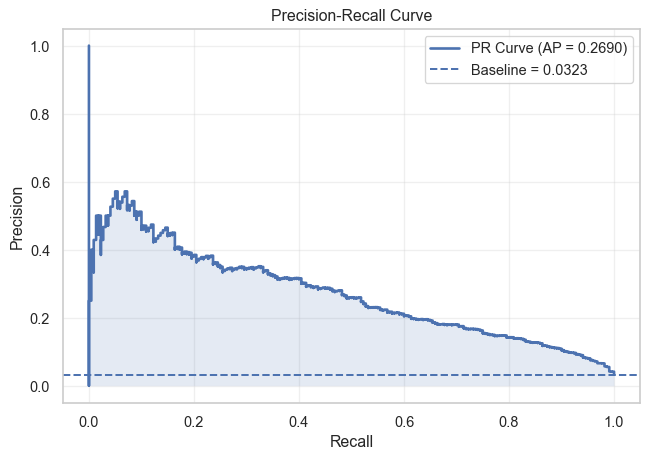

In [49]:
y_true = df_z_raw['Target_Bankrupt']
y_scores = -df_z_raw['Z_Score']

precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
ap_score = average_precision_score(y_true, y_scores)
positive_rate = y_true.mean()

plt.figure(figsize=(7, 5), dpi=95)

plt.step(
    recall,
    precision,
    where='post',
    linewidth=2,
    label=f'PR Curve (AP = {ap_score:.4f})'
)

plt.fill_between(
    recall,
    precision,
    step='post',
    alpha=0.15
)

plt.axhline(
    y=positive_rate,
    linestyle='--',
    linewidth=1.5,
    label=f'Baseline = {positive_rate:.4f}'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

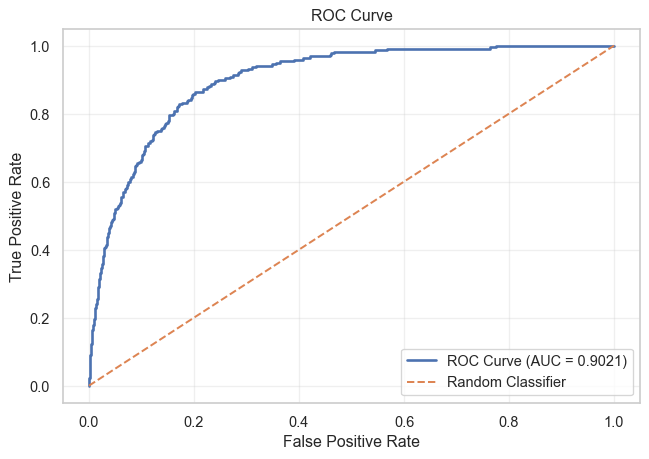

In [50]:
y_true = df_z_raw['Target_Bankrupt']
y_scores = -df_z_raw['Z_Score']

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = roc_auc_score(y_true, y_scores)

plt.figure(figsize=(7, 5), dpi=95)

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'ROC Curve (AUC = {roc_auc:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1.5,
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

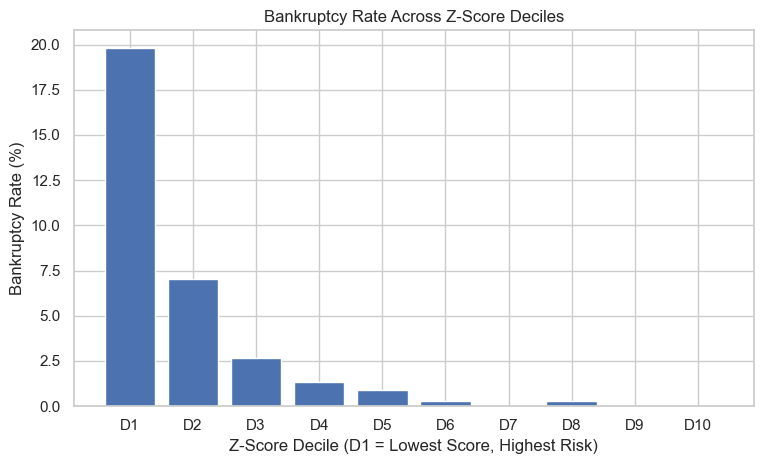

In [51]:
plt.figure(figsize=(7.8, 4.8))
plot_df = decile_table.reset_index()

plt.bar(plot_df['Risk_Decile'].astype(str), plot_df['Bankruptcy_Rate_%'])
plt.title('Bankruptcy Rate Across Z-Score Deciles')
plt.xlabel('Z-Score Decile (D1 = Lowest Score, Highest Risk)')
plt.ylabel('Bankruptcy Rate (%)')
plt.tight_layout()
plt.show()

### 6.4 Z-Score Distribution by Firm Status

The density plot below compares the full distribution of Z-Scores between non-bankrupt and bankrupt observations. The more clearly the two curves separate, the more useful the score is as a screening indicator.


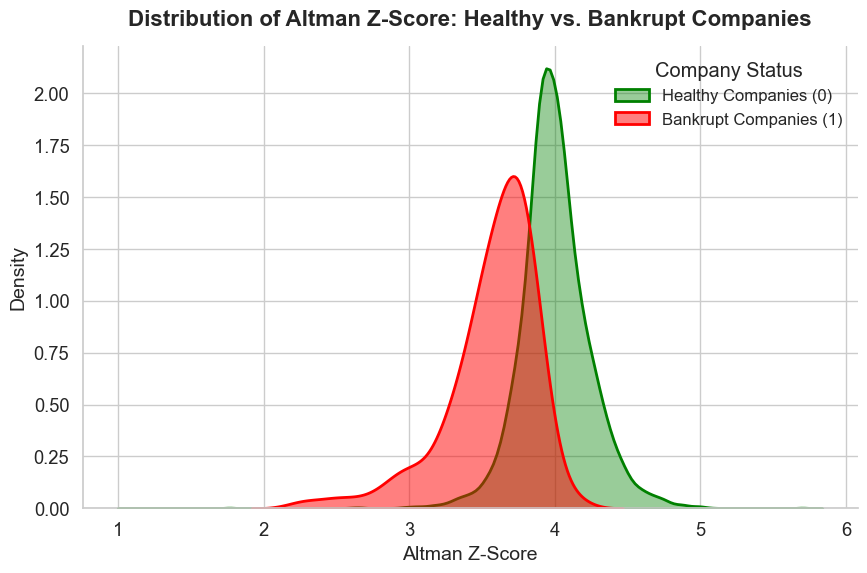

In [52]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

plt.figure(figsize=(10, 6))

sns.kdeplot(data=df_z_raw[df_z_raw['Target_Bankrupt'] == 0], x='Z_Score', 
            fill=True, color='green', alpha=0.4, label='Healthy Companies (0)', linewidth=2)

sns.kdeplot(data=df_z_raw[df_z_raw['Target_Bankrupt'] == 1], x='Z_Score', 
            fill=True, color='red', alpha=0.5, label='Bankrupt Companies (1)', linewidth=2)

plt.title('Distribution of Altman Z-Score: Healthy vs. Bankrupt Companies', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Altman Z-Score', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(title='Company Status', fontsize=12)

sns.despine()

plt.show()

### 6.5 Correlation Structure

Spearman correlation is used because financial ratios can be non-normal and sensitive to outliers. The focus here is not causal inference. It is to see which score components move most strongly with bankruptcy status in a rank-based sense.


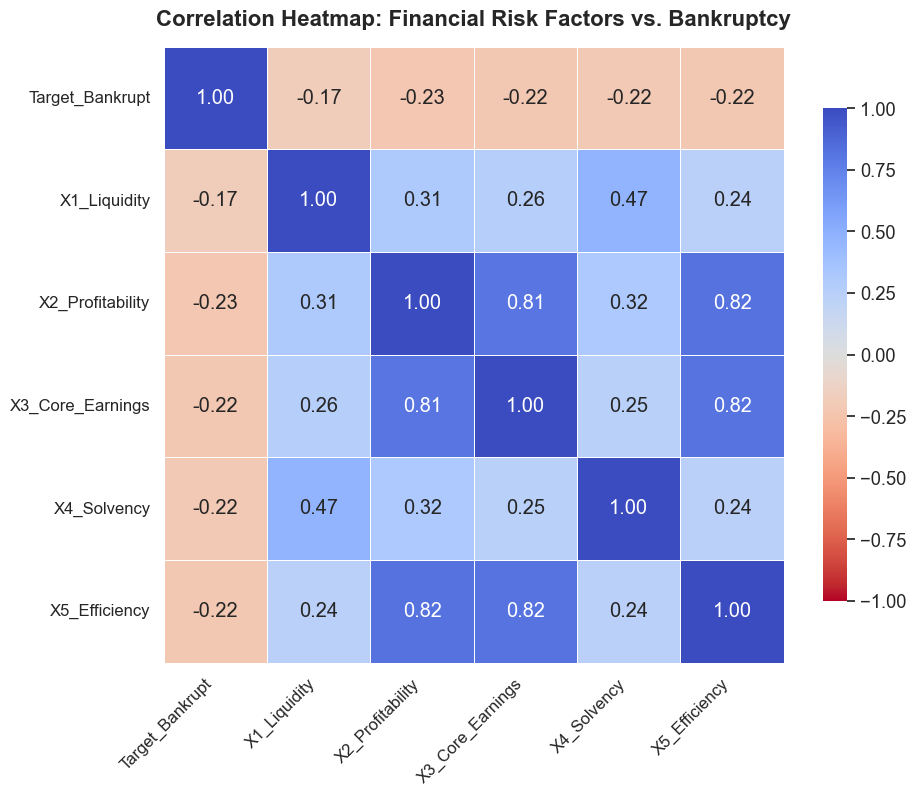

In [53]:

corr_cols = ['Target_Bankrupt', 'X1_Liquidity', 'X2_Profitability', 
             'X3_Core_Earnings', 'X4_Solvency', 'X5_Efficiency']


corr_matrix = df_z_raw[corr_cols].corr(method='spearman')


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm_r', fmt='.2f', 
            linewidths=0.5, vmin=-1, vmax=1, cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap: Financial Risk Factors vs. Bankruptcy', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.show()

As shown in the figure, the direct correlation coefficient between a single financial indicator and the bankruptcy label is low. This reveals a core characteristic of corporate financial distress: bankruptcy is not caused by a slight deterioration of a single financial indicator. Traditional single-factor analysis fails when dealing with highly imbalanced default data. This also indirectly proves why we need to introduce a multi-factor composite model like Altman Z-Score - only by combining the marginal changes in liquidity, profitability, and leverage, etc., can the true signal of the break in the company's capital chain be captured.

### 6.6 Component-Level Comparison

The boxplots below compare all five score components between healthy and bankrupt firms. This helps identify which underlying financial dimensions show the clearest structural differences across the two groups. Rather than relying only on the composite score, this section shows how liquidity, retained profitability, earnings power, solvency, and operating efficiency each contribute to overall distress separation.


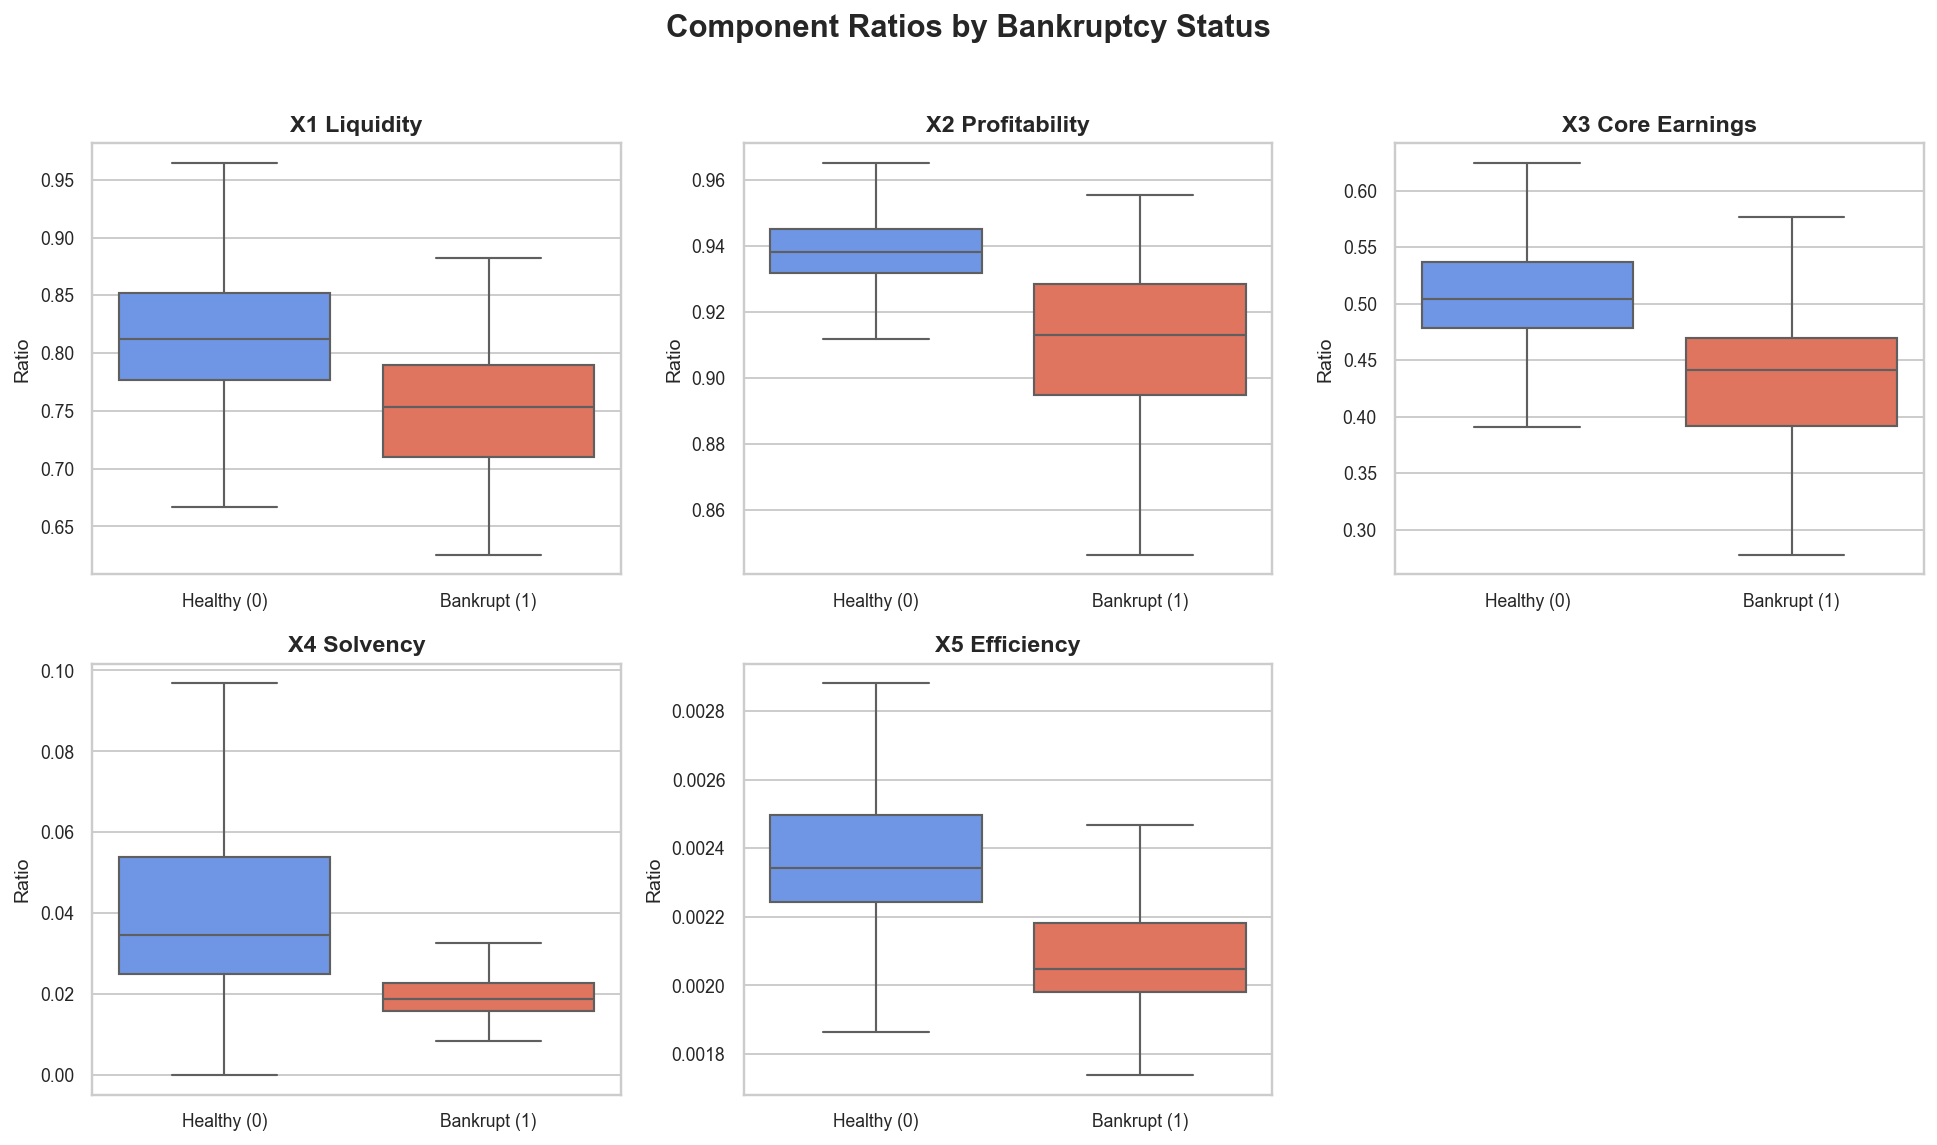

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

plot_vars = [
    ('X1_Liquidity', 'X1 Liquidity'),
    ('X2_Profitability', 'X2 Profitability'),
    ('X3_Core_Earnings', 'X3 Core Earnings'),
    ('X4_Solvency', 'X4 Solvency'),
    ('X5_Efficiency', 'X5 Efficiency')
]

palette_map = {
    0: '#5B8FF9',
    1: '#F4664A'
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=140)
axes = axes.flatten()

for ax, (col, title) in zip(axes, plot_vars):
    sns.boxplot(
        data=df_z_raw,
        x='Target_Bankrupt',
        y=col,
        hue='Target_Bankrupt',
        dodge=False,
        palette=palette_map,
        showfliers=False,
        linewidth=1.1,
        ax=ax
    )

    if ax.legend_ is not None:
        ax.legend_.remove()

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Ratio', fontsize=10)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Healthy (0)', 'Bankrupt (1)'], fontsize=9)

    ax.tick_params(axis='y', labelsize=9)

fig.delaxes(axes[-1])

fig.suptitle('Component Ratios by Bankruptcy Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.7 Classical Risk-Zone Reference

This table reports the classical Altman distress, grey, and safe zones only as a reference classification. Because the available variables in this dataset are scaled proxy ratios rather than the exact original accounting inputs, the classical cutoffs may not fit the sample well. Therefore, this notebook reports the traditional zones for completeness, but later places more emphasis on ranking performance and decile-based risk gradients.

In [55]:
risk_zone_table = (
    df_z_raw.groupby('Risk_Zone', observed=False)['Target_Bankrupt']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={'count': 'Observations', 'sum': 'Bankrupt_Count', 'mean': 'Bankruptcy_Rate'})
    .round(4)
)

risk_zone_table['Bankruptcy_Rate_%'] = (risk_zone_table['Bankruptcy_Rate'] * 100).round(2)
risk_zone_table


,Observations,Bankrupt_Count,Bankruptcy_Rate,Bankruptcy_Rate_%
Risk_Zone,,,,
Distress,3,0,0.0000,0.00
Grey,23,14,0.6087,60.87
Safe,6793,206,0.0303,3.03


## 7. Robustness Check

Because financial ratios can contain extreme values, this section checks whether the main result still holds after winsorizing the five component ratios at the 1st and 99th percentiles. The key question is whether bankrupt firms still have lower scores and whether the score still ranks bankruptcy risk well after the influence of extreme observations is reduced.

In [56]:
z_status_summary_robust = (
    df_z_winsor.groupby('Target_Bankrupt')['Z_Score']
    .agg(['mean', 'median', 'std', 'count'])
    .round(4)
)

auc_robust = roc_auc_score(df_z_winsor['Target_Bankrupt'], -df_z_winsor['Z_Score'])
pr_auc_robust = average_precision_score(df_z_winsor['Target_Bankrupt'], -df_z_winsor['Z_Score'])

df_z_winsor['Risk_Decile'] = pd.qcut(
    df_z_winsor['Z_Score'],
    10,
    labels=[f'D{i}' for i in range(1, 11)],
    duplicates='drop'
)

decile_table_robust = (
    df_z_winsor.groupby('Risk_Decile', observed=False)['Target_Bankrupt']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={'count': 'Observations', 'sum': 'Bankrupt_Count', 'mean': 'Bankruptcy_Rate'})
    .round(4)
)

decile_table_robust['Bankruptcy_Rate_%'] = (decile_table_robust['Bankruptcy_Rate'] * 100).round(2)

print("Z-Score summary after winsorization:")
display(z_status_summary_robust)

print(f"Robust ROC-AUC: {auc_robust:.4f}")
print(f"Robust PR-AUC: {pr_auc_robust:.4f}")

print("Decile-based bankruptcy rates after winsorization:")
display(decile_table_robust)

Z-Score summary after winsorization:


,mean,median,std,count
Target_Bankrupt,,,,
0,3.9974,3.9829,0.2275,6599
1,3.6102,3.6411,0.2146,220


Robust ROC-AUC: 0.9046
Robust PR-AUC: 0.2851
Decile-based bankruptcy rates after winsorization:


,Observations,Bankrupt_Count,Bankruptcy_Rate,Bankruptcy_Rate_%
Risk_Decile,,,,
D1,682,133,0.1950,19.50
D2,682,51,0.0748,7.48
D3,682,18,0.0264,2.64
D4,682,9,0.0132,1.32
D5,682,6,0.0088,0.88
D6,681,2,0.0029,0.29
D7,682,0,0.0000,0.00
D8,682,1,0.0015,0.15
D9,682,0,0.0000,0.00


The winsorized results remain very close to the raw-data results. Bankrupt firms still have lower scores, and the ranking metrics remain strong. This suggests that the main conclusion is not driven by a small number of extreme observations.


## 8. Key Findings

**Finding 1 — Bankrupt firms have consistently lower Altman-style distress scores than non-bankrupt firms.**  
The mean score is **3.5660** for bankrupt firms and **3.9977** for non-bankrupt firms. The median values show the same pattern, at **3.6355** versus **3.9829**. This indicates that firms labelled as bankrupt tend to have systematically weaker overall financial profiles in this sample.

**Finding 2 — The score shows strong ranking ability even in a highly imbalanced dataset.**  
Only **3.23%** of observations are bankrupt, so simple accuracy would be misleading. However, the score achieves a **ROC-AUC of 0.9021** and a **PR-AUC of 0.2690**, which suggests that lower scores are strongly associated with higher bankruptcy risk.

**Finding 3 — Relative ranking works better than direct use of the classical Altman cutoffs in this dataset.**  
The classical distress, grey, and safe zones are not very informative here because almost all observations fall into the safe zone. By contrast, the decile analysis shows a clear gradient. The lowest-score decile has a bankruptcy rate of **19.79%**, while the highest-score deciles are close to **0%**. This means the score is useful mainly as a **relative risk-ranking tool** rather than a literal application of the original cutoff thresholds.


## 9. Conclusion

This notebook applies an adapted Altman-style distress score to **6,819** firm observations and finds that the score has clear screening value in this sample. Bankrupt firms show consistently lower scores than non-bankrupt firms, and the score achieves a **ROC-AUC of 0.9021**, indicating strong ranking ability.

After winsorizing the five component ratios, the main result remains almost unchanged. Bankrupt firms still have lower scores, and the ranking performance remains strong, which supports the robustness of the core conclusion.

At the same time, the classical Altman cutoff zones are not very suitable for this dataset. Most observations fall into the safe zone because the available variables are scaled proxy ratios rather than the exact original accounting items used in the original model. For this reason, decile-based risk grouping is more informative here than direct use of the original 1.81 and 2.99 thresholds.

Overall, the project shows that an adapted Altman-style score can serve as a **transparent early-warning screening tool**, but its interpretation should rely more on relative ranking than on literal application of the original cutoff values.


## 10. Limitations

This project has several important limitations.

First, the notebook does not use the exact original Altman inputs in raw statement form. Some variables are represented by the closest available ratios in the dataset, and the data appear to contain scaled features rather than raw accounting numbers. As a result, the composite score should be interpreted as an adapted Altman-style index rather than a literal reconstruction of the original public-firm model.

Second, the score is not recalibrated for the current dataset, and the original Altman framework was initially developed for manufacturing firms rather than modern service, internet, or other asset-light companies. This creates a potential recalibration problem, because both the original coefficients and the classical cutoff values were derived in a different industrial and historical setting. In addition, the current notebook does not control for broader macroeconomic conditions or business-cycle effects, which may also influence bankruptcy risk independently of firm-level accounting ratios. These factors help explain why the classical distress, grey, and safe zones do not align well with the present sample.

Third, the score relies entirely on accounting-based variables, which are inherently backward-looking and may not fully capture real-time changes in firm risk. In addition, accounting measures may be affected by **earnings management** or window dressing, especially when firms are already under financial pressure. This means the score may miss forward-looking market signals and may also be sensitive to reporting choices made by management.

Finally, the robustness analysis in this notebook is still limited. Winsorization improves stability and shows that the main findings are not driven by a small number of extreme observations, but it is only one robustness check. Additional validation approaches could still lead to somewhat different conclusions.

## 11. Possible Improvements

Several extensions could strengthen this project.

**Compare Altman Z-Score with a simple benchmark model.**  
For example, add a logistic regression model and compare whether the classical score or the statistical model separates bankrupt firms more clearly.

**Add predictive evaluation metrics.**  
You can split the data into training and testing sets, then evaluate AUC, precision, recall, and confusion matrices. This would move the notebook from descriptive screening toward formal prediction.

**Use more detailed firm context.**  
Industry, year, and firm identifiers would allow a better understanding of whether the result is stable across sectors and time.

**Build a small user-facing product.**  
For Track 2, you can turn the notebook into a GitHub project with a README that explains the workflow and a short demo video that shows how a user can interpret the Z-Score and risk zones.
